In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!pip install tiktoken

In [3]:
import tiktoken

In [4]:
# GPT4's tokenizer
tokenizer = tiktoken.get_encoding("cl100k_base")

In [5]:
tokenizer.n_vocab

100277

In [6]:
tokenizer.encode("Hello World!")

[9906, 4435, 0]

In [7]:
tokenizer.eot_token

100257

In [12]:
tokenizer.decode([3455, 46781])

'change webdriver'

## Tokenization

In [13]:
text = "My name is Tung and I like playing football"
tokens = tokenizer.encode(text)
print(tokens)

[5159, 836, 374, 350, 2234, 323, 358, 1093, 5737, 9141]


In [14]:
for word in text.split():
  print(f"{word} comprises token(s): {tokenizer.encode(word)}")

My comprises token(s): [5159]
name comprises token(s): [609]
is comprises token(s): [285]
Tung comprises token(s): [51, 2234]
and comprises token(s): [438]
I comprises token(s): [40]
like comprises token(s): [4908]
playing comprises token(s): [43012]
football comprises token(s): [85436]


In [19]:
# special charaters non-ASCII
tokenizer.encode("â")

[9011]

## How long are the tokens ?

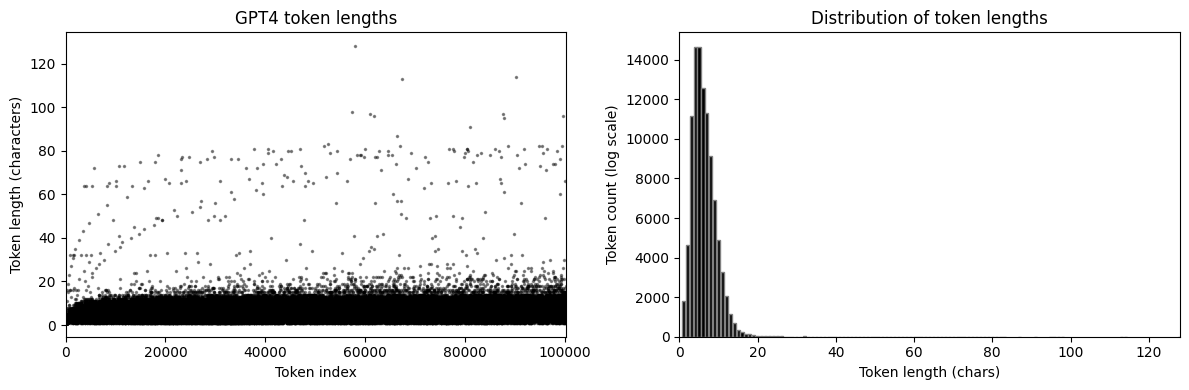

In [30]:
# initialize lengths vector
token_lengths = np.zeros(tokenizer.n_vocab)

# get the number of characters in each token
for idx in range(tokenizer.n_vocab):
  try:
    token_lengths[idx] = len(tokenizer.decode([idx]))
  except:
    token_lengths[idx] = np.nan

# count unique lengths
uniqueLengths,tokenCount = np.unique(token_lengths,return_counts=True)



# visualize
_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].plot(token_lengths,'k.',markersize=3,alpha=.4)
axs[0].set(xlim=[0,tokenizer.n_vocab],xlabel='Token index',ylabel='Token length (characters)',
           title='GPT4 token lengths')

axs[1].bar(uniqueLengths,tokenCount,color='k',edgecolor='gray')
axs[1].set(xlim=[0,max(uniqueLengths)],xlabel='Token length (chars)',ylabel='Token count (log scale)',
           title='Distribution of token lengths')

plt.tight_layout()
plt.show()